# Llamatron: The Insides

In [321]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:50% !important; }</style>"))

## Let's Start with Sprites

To understand sprites, the cornerstone of graphics in Llamatron, we're going to look at how we set up a palette of colors for the game and then understand how we setup the data for our sprites to define colourful pictures to display to the player.

One of the first things Llamatron does is set up its palette. The Atari STE allows you to define a palette of 16 colors. So what we can do is choose which of the 4096 colors we want to use. This is the relevant code. 

```asm
                ; Our palette of 16 colors
game_pal:       dc.w $0000,$0717,$0700,$0750,$0770,$0D34,$00C0,$007C
                dc.w $0077,$00C7,$0223,$0007,$0507,$0775,$0777,$0555
                ..
                move.l #game_pal,a0      ; Store a pointer to the palette in a0.
                jsr setpal               ; Call setpal to copy game_pal to the palette.
                ..
                ; The palette is stored in registers $ff8240 to $ff824e. One register per colour.
                ; a0 is a pointer to the palette we are copying from (game_pal in this instance).
setpal:         lea $ff8240,a1           ; Store pointer to first color register in a1.
                move #15,d1              ; Use d1 as our index, we start at the last register so we start at 15.
set_loop:       move (a0)+,(a1)+         ; Copy the entry in a0 (game_pal) to the current register.
                dbra d1,set_loop         ; Decrement index to go the next regiser, and loop until finished.
                rts
```

Notice the rather odd way of defining color values in `game_pal`. Knowing that they are RGB values we can guess that the last three nibbles in each word represent Red, Green, and Blue values respectively. So for example `$0717` might mean a red value of 7, a green value of 1, and a blue value of 7. This is almost correct, but the truth is slightly more complicated. In fact the bits for each color are given slightly out of order, with the lowest order bit in the most significant position. So to get the actual value for each of red, green , and blue we need to correct them in the manner below.

```
                     | .... |rRRR |gGGG | bBBB
Hex Value            | 0    | 7   | 1   | 7 
Bits                 | 0000 |0111 |0001 | 0111
Corrected Bits       | 0000 |1110 |0010 | 1110
Corrected Hex Value  | 0    | E   | 2   | E
```

Let's see what each of the RGB values in `game_pal` actually translates to.

In [291]:
# Get the rgb words in game_pal
game_pal = """
game_pal:
        dc.w $0000,$0717,$0700,$0750,$0770,$0D34,$00C0,$007C
        dc.w $0077,$00C7,$0223,$0007,$0507,$0775,$0777,$0555
""".split('\n')[2:-1]
# Convert them to a list, e.g. ['0000','0717', '0700', etc.]
color_words = [w[2:] for l in game_pal for w in l.strip()[5:].split(',')]

def get_rgb(nibble):
    """
    Convert a 4-bit Atari STE RGB value of the form ''....rRRR gGGGbBBB'
    to an 8-bit RGB value we can use to display graphics here.
    """
    lsb = (nibble & 0x08) >> 3
    msbs = (nibble & 0x07) << 1
    return (msbs | lsb) * 16 # Multiply by 16 to map it to 0..255

# Convert them to rgb values between 0 and 255
rgb_palette = [tuple([get_rgb(int(n,16)) for n in w]) for i, w in enumerate(color_words)]

# Display them.
rgb_palette

[(0, 0, 0),
 (224, 32, 224),
 (224, 0, 0),
 (224, 160, 0),
 (224, 224, 0),
 (176, 96, 128),
 (0, 144, 0),
 (0, 224, 144),
 (0, 224, 224),
 (0, 144, 224),
 (64, 64, 96),
 (0, 0, 224),
 (160, 0, 224),
 (224, 224, 160),
 (224, 224, 224),
 (160, 160, 160)]

With our 4-bit (0-16) RGB values mapped to their 8-bit (0-255) equivalents, we can take a look at what colors our palette contains.

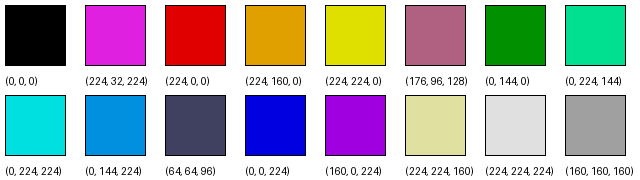

In [290]:
from PIL import Image, ImageDraw

img = Image.new( 'RGB', (len(rgb_palette) * 40, 180), color="white")
draw = ImageDraw.Draw(img)

# Display the colors in rgb_palette.
x,y = 5,5
for color in rgb_palette:
    draw.rectangle([(x,y), (x + 60, y + 60)], fill = color, outline="black")
    draw.text((x, y + 70), str(color), fontsize=14, fill="black")
    x += 80
    if x > 640: 
        y += 90
        x = 5
img

Now that we have our colours, let's see how we can use them to display something. Here is the sprite definition for the player's avatar in llamatron, a dinky little llama.

```
lla1:           dc.w 3,0,17,14,0,0
                dc.w $0008,$0000,$0008,$0000,$0010,$0000,$0010,$0000
                dc.w $0018,$0008,$0010,$0000,$003C,$001C,$0020,$0000
                dc.w $0030,$0010,$0020,$0000,$0030,$0000,$0030,$0000
                dc.w $C030,$C000,$0030,$0000,$2038,$2020,$0018,$0000
                dc.w $3FF8,$00E0,$3F18,$0F00,$1FF8,$0000,$1FF8,$1E00
                dc.w $1FF8,$0000,$1FF8,$0C00,$1FF0,$0C00,$13F0,$0000
                dc.w $3828,$1800,$2028,$0000,$3428,$0000,$3428,$0000
                dc.w $282C,$0000,$282C,$0000,$2824,$0000,$2824,$0000
                dc.w $3026,$0000,$3026,$0000,$0C30,$0000,$0C30,$0000

```

In [ ]:
lla1 = """
lla1:           dc.w 3,0,17,14,0,0
                dc.w $0008,$0000,$0008,$0000,$0010,$0000,$0010,$0000
                dc.w $0018,$0008,$0010,$0000,$003C,$001C,$0020,$0000
                dc.w $0030,$0010,$0020,$0000,$0030,$0000,$0030,$0000
                dc.w $C030,$C000,$0030,$0000,$2038,$2020,$0018,$0000
                dc.w $3FF8,$00E0,$3F18,$0F00,$1FF8,$0000,$1FF8,$1E00
                dc.w $1FF8,$0000,$1FF8,$0C00,$1FF0,$0C00,$13F0,$0000
                dc.w $3828,$1800,$2028,$0000,$3428,$0000,$3428,$0000
                dc.w $282C,$0000,$282C,$0000,$2824,$0000,$2824,$0000
                dc.w $3026,$0000,$3026,$0000,$0C30,$0000,$0C30,$0000
"""

In [313]:
"""
Read in all the sprite definitions in Llamatron's main source file `LLATRON.S` and turn them into a dictionary of
sprite names with the corresponding sprite definition data and the sprite type.
"""
src_file = open("LLATRON.S",'r')
src_lines = src_file.readlines()

# Get the lines with the sprites in them
sprite_lines = src_lines[9429:10930] + src_lines[11007:13943]

# Get a list of the sprite labels, their position in the file, and the sprite type.
char_labels = [(x.split(':')[0], i, int(x.split(',')[1])) 
               for i,x in enumerate(sprite_lines) if ":" in x]

def get_sprite_data(start, end):
    """
    Turn raw lines of sprite data into a list of 16-bit integers that we
    can use to create the sprite bitmaps.
    """
    raw_sprite_data = [l for l in sprite_lines[start+1:end] if l.strip()]
    sprite_data = [y.strip()[1:] for x in raw_sprite_data for y in x.strip()[4:].split(',')]
    sprite_def_data = [int(y,16) for y in sprite_data]
    return sprite_def_data

# Create a dictionary of sprite definitions keyed on sprite name.
sprite_definitions = {n: (get_sprite_data(s,e), t) 
                      for (n,s,t),(_,e,_) in pairwise(char_labels)}

In [318]:
from itertools import pairwise 
from PIL import Image, ImageColor, ImageFont, ImageDraw

# Create a look-up table for our RGB values.
rgb_palette = {format(i,f"004b") : tuple([get_rgb(int(n,16)) for n in w])
               for i, w in enumerate(color_words)}

# A hack for the width of the sprite until I figure out the right way.
width_map = {0:16, 1:32, 3:64, 4:80, 5:96, 6:112, 19:160}
def draw_sprite(sprite_name, scale=10):
    """
    Given the name of a sprite, draw it.
    """
    sprite_data, sprite_type = sprite_definitions[sprite_name]
    width = width_map[sprite_type]
    slice_len = 4

    bit_quads = []
    for i in range(0, len(sprite_data), slice_len):
        nibbles = tuple([format(b,f"016b") for b in reversed(sprite_data[i:i + slice_len])])
        bit_quads += [''.join(x) for x in zip(*nibbles)]
        
    sprite_lines = [
        bit_quads[i:i+width] 
        for i in range(0, len(bit_quads), width)
    ]
    
    height = len(sprite_lines)
    img = Image.new( 'RGBA', (width, height))
    pixels = img.load()
    for y, line in enumerate(sprite_lines):
        for x, bit in enumerate(line):
            if bit == "0000": continue
            pixel_color = rgb_palette[bit]
            pixels[x,y] = pixel_color
            
    img = img.resize((img.width * scale, img.height * scale), Image.NEAREST)
    return img

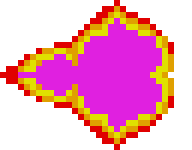

In [325]:
draw_sprite("mandy1",6)

In [196]:
objex = """
objex:  dc.l ls1,ls2,ls3,ls4,ls5,ls6,ls7,ls8                ;7
        dc.l lg1,lg2,lg3,lg4,lg5,lla4,lla3,lla2                ;15
        dc.l lla1,lla5,lla6,lla7,lla8,lla9,lla10,lla11        ;23
        dc.l lla12,lla13,lla14,lla15,lla16,bul1,bul2,bul3        ;31
        dc.l bul4,lec1,coke1,tlla1,tlla2,tlla3,tlla4,tlla5        ;39
        dc.l tlla6,tlla7,tlla8,kil1,kil2,kil3,kil4,kil5                ;47
        dc.l kil6,kil7,kil8,skull,kil9,kil10,kil11,kil12,kil13        ;56
        dc.l kil14,kil15,kil16,fhg1,fhg2,fhg3,fhg4        ;63
        dc.l fhy,fhyp1,fhyp2,fhyp3,fhyp4,fhb,thoub        ;70
        dc.l goat1,goat2,goat3,goat4,goat5,goat6,goat7,goat8        ;78
        dc.l ram1,ram2,ram3,ram4,ram5,ram6,ram7,ram8        ;86
        dc.l caml1,caml2,caml3,caml4,caml5,caml6,caml7,caml8        ;94
        dc.l p2cam1,p2cam2,p2cam3,p2cam4,p2cam5,p2cam6,p2cam7,p2cam8        ;102
        dc.l p2cam9,p2cam10,p2cam11,p2cam12,p2cam13,p2cam14,p2cam15,p2cam16        ;110
        dc.l bug1,bug2,bug3,bug4,bug5,bug6,bug7,bug8        ;118
        dc.l spik1,spik2,spik3,spik4                ;122
        dc.l glob1,glob2,glob3,glob4,glob5,glob6,glob7,glob8        ;130
        dc.l glob9,glob10,glob11,glob12,lazr,ylazr        ;136
        dc.l yy1,yy2,yy3,yy4,yy5,yy6,yy7,yy8,yyp1,yyp2,yyp3,yyp4        ;148
        dc.l blokr1,blokr2,blokr3,blokr4        ;152
        dc.l mutnt1,mutnt2,mutnt3,mutnt4,mutnt5,mutnt6,mutnt7,mutnt8        ;160
        dc.l splat1,splat2,brane1,brane2,brane3,brane4,brane5        ;167
        dc.l brane6,brane7,brane8,spark1,spark2,spark3,spark4        ;174
        dc.l dot1,dot2,dot3,dot4,bog1,bog2,roll1,roll2,turd1,turd2        ;184
        dc.l turd3,turd4,bul21,bul22,bul23,bul24,mine        ;191
        dc.l bbul1,bbul2,bbul3,bbul4,luv1,luv2        ;197
        dc.l bsh1,bsh2,bsh3,bsh4,bsh5,bsh6,bsh7,bsh8        ;205
        dc.l teap1,teap2,teap3,teap4,eyb2,eyb1,eyb3,eyb3        ;213
        dc.l lik2,lik1,lik3,lik3,ski2,ski1,ski3,ski3        ;221
        dc.l gblok1,gblok2,fteeth1,fteeth2,fteeth3,fteeth2        ;227
        dc.l fteeth4,gproj1,gproj2,aro1,aro2,aro3,aro4                ;234
        dc.l lsplat1,lsplat2,lsplat3,lsplat4,robo1        ;239
        dc.l wpod1,wpod2,lpod1,lpod2,hbike,hbike        ;245
        dc.l f3way1,f3way2,smbom1,smbom2,invis1,invis2        ;251
        dc.l mandy1,mandy2,mbuu1,mbuu2,bsi1,bsi2        ;257
        dc.l bnus1,bnus2,trn1,trn2,trn3,trn4,trn5,trn6,trn7,trn8        ;267
        dc.l saf1,saf2,saf3,w16ton,brolly1,brolly2,drop        ;274
        dc.l camsaf1,camsaf2,camsaf3,camspit1,camspit2        ;279
        dc.l ro1,ro2,ro3,ro4,bait1,bait2,bait3,bait4        ;287
        dc.l scros1,scros2,sfhg1,sfhg2,sfhg3,sfhg2        ;293
        dc.l sgun1,sgun2,sgun3,sgun4,gproj                ;298
        dc.l nki1,nki2,nki3,nki4,nki5,nki6,nki7,nki8        ;306
        dc.l nel1,nel2,nel3,strn1,strn2,strn3,strn4        ;313
        dc.l strn5,strn6,strn7,strn8,tseg1,tseg2,tseg3,tseg4        ;321
        dc.l tseg5,tseg6,tseg7,tseg8,thead,xxx1,xxx2,xxx3        ;329
        dc.l lla4,lla3,lla2
        dc.l lla1,lla5,lla6,lla7,lla8,lla9,lla10,lla11
        dc.l lla12,lla13,lla14,lla15,lla16
        dc.l p2cam1,p2cam2,p2cam3,p2cam4,p2cam5,p2cam6,p2cam7,p2cam8
        dc.l p2cam9,p2cam10,p2cam11,p2cam12,p2cam13,p2cam14,p2cam15,p2cam16
        dc.l droi1,droi2,droi3,mine,bul21,bul22,bul23,bul24
        dc.l bbul1,bbul2,bbul3,bbul4,-1
""".split('\n')[1:-1]
objex_list = [w.strip() for l in objex for w in l[12:].split(';')[0].split(',')]

### Draw the Title Marquee
The title marquee is made up of sprites `lla1` to `lla6`. The array `titty` gives the index in `objex` for each sprite in the title. We can extract the sprite names into a list as follows.

In [224]:
titty = """
titty:  dc.w -1,-1,-1,-1,-1,-1,-1,-1,-1,-1 
        dc.b 0,0,1,2,1,3,4,5,6,7
""".split('\n')[2:-1]
title_list = [objex_list[int(b)] for l in titty for b in l[12:].split(',')]
title_list

['ls1', 'ls1', 'ls2', 'ls3', 'ls2', 'ls4', 'ls5', 'ls6', 'ls7', 'ls8']

Armed with this we can now draw the title.

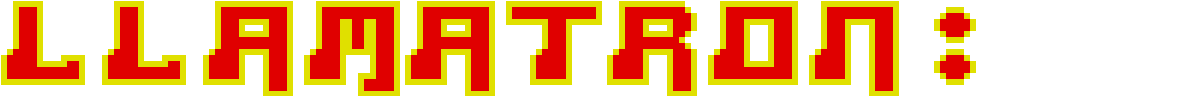

In [326]:
x = 1
img = Image.new( 'RGBA', (len(title_list) * 6 * 20, 16 * 6))
for sprite in title_list:
    simg = draw_sprite(sprite,6)
    img.paste(simg, (x,1))
    x += simg.width + 5
img

### Draw the Logo

```asm
drawlogo:       lea objex,a3          ; Store ptr to objex array in a3.
                move #1,d2
                move #44,d1           ; 44 is our X position.
                move #130,d0          ; 130 is our Y position
                move #8,d5            ; Start from item 8 in objex.
drawl:          move d5,d6            ; Store index in d6.
                asl #2,d6             ; Multiply it by 2.
                move.l 0(a3,d6.w),a0  ; Use it to fetch the sprite from objex.
                bsr syak              ; Draw the sprite
                neg d4
                bsr syak              ; Draw the sprite.
                neg d4
                add #16,d0            ; 
                add #1,d5             ; Increment the index.
                cmp #13,d5            ; Have we reached item 13 yet?
                bne drawl             ; If not, keep looping.
                rts
```

In [231]:
logo_list = [objex_list[i] for i in range(8,13)]
logo_list

['lg1', 'lg2', 'lg3', 'lg4', 'lg5']

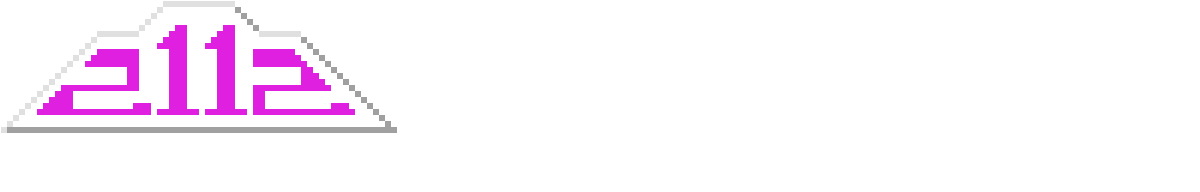

In [232]:
x = 1
img = Image.new( 'RGBA', (len(title_list) * 6 * 20, 32 * 6))
for s in logo_list:
    simg = draw_sprite(s,6)
    img.paste(simg, (x,1))
    x += simg.width - 6
img

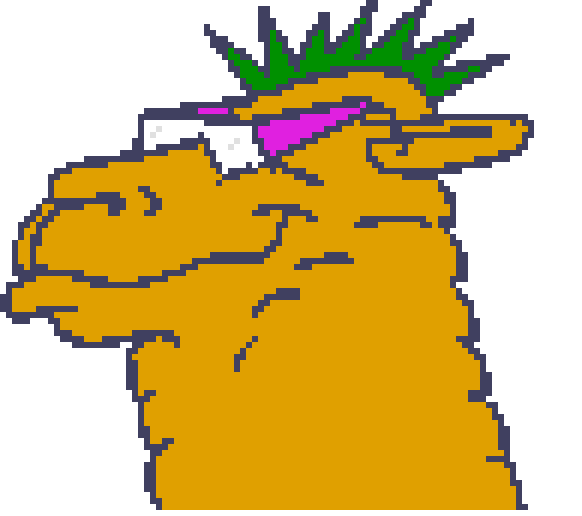

In [182]:
draw_sprite("coolc1",6)